# U18 — Clustering (finish): Lab

### Real-world brief: grouping machine vibration signatures into fault families

A reliability team collects **vibration signatures** from rotating machines — RMS energy, peak acceleration, crest factor, kurtosis, dominant-frequency order, high-frequency energy. There are no labels, but engineers know faults fall into **families** (imbalance, misalignment, bearing defect…) that form clusters of *different shapes and densities*, with occasional sensor **glitches** that belong to no group. Plain k-means (Part 1) assumes round, equal blobs — here you'll use the Part 2 toolkit: **hierarchical clustering, DBSCAN and Gaussian Mixtures**.

**Resource provided:** `vibration_signatures.csv` (one row per reading, 6 features, **no labels**). Keep it beside this notebook (upload it in Colab).

_Phase E — Unsupervised Learning (Clustering, Part 2)._

#objectives

Build a dendrogram and cut it into fault families

Compare linkage methods for hierarchical clustering

Use DBSCAN to find arbitrary shapes and flag noise/outliers

Fit a Gaussian Mixture for soft (probabilistic) cluster membership

Compare k-means, DBSCAN and GMM on the same data

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_vibration(csv_path="vibration_signatures.csv", seed=182, verbose=False):
    """Vibration condition-monitoring signatures from rotating machinery — an UNLABELLED
    clustering dataset built for U18 Part 2 (hierarchical, DBSCAN, GMM).

    Designed so that:
      - fault families form clusters of DIFFERENT shape & density (GMM / DBSCAN shine,
        plain k-means struggles),
      - a sprinkling of scattered NOISE readings exist (DBSCAN should flag them as outliers),
      - features sit on different scales (scaling lesson carries over).

    Features (typical vibration-analysis descriptors):
      rms_mm_s          overall vibration energy (mm/s)
      peak_g            peak acceleration (g)
      crest_factor      peak / rms  (impulsiveness)
      kurtosis          spikiness of the waveform
      dom_freq_orders   dominant frequency as a multiple of running speed (1x, 2x, ...)
      hf_energy_pct     % energy in the high-frequency band (bearing tones)
    No label column — the fault regime is what clustering should reveal.
    """
    rng = np.random.default_rng(seed)

    def blob(n, mu, sd, shape=None):
        X = rng.normal(0, 1, size=(n, len(mu)))
        if shape is not None:        # elongate / correlate to make it non-spherical
            X = X @ shape
        return X * sd + mu

    # fault families (rms, peak_g, crest, kurt, dom_freq_orders, hf_energy_pct)
    healthy = blob(360, [1.4, 0.3, 3.0, 3.0, 1.0, 8],  [0.3, 0.08, 0.4, 0.4, 0.05, 2])
    # imbalance: strong 1x, low crest, fairly tight, ELONGATED along rms
    imbalance = blob(300, [5.0, 1.0, 3.2, 3.1, 1.0, 10],
                     [1.4, 0.2, 0.3, 0.3, 0.04, 3],
                     shape=np.diag([1.0, 0.3, 0.3, 0.3, 0.3, 0.6]))
    # misalignment: 2x dominant, moderate
    misalign = blob(260, [4.2, 1.2, 3.8, 3.6, 2.0, 14], [0.8, 0.25, 0.5, 0.5, 0.06, 3])
    # bearing defect: high crest/kurtosis, high-frequency energy, sparse & spread (low density)
    bearing = blob(150, [3.2, 2.6, 6.5, 8.0, 4.5, 45], [0.9, 0.7, 1.3, 2.2, 1.2, 12])

    X = np.vstack([healthy, imbalance, misalign, bearing])

    # scattered noise readings (sensor glitches / transient events) -> DBSCAN should call these noise
    lo = X.min(0); hi = X.max(0)
    noise = rng.uniform(lo, hi, size=(60, X.shape[1]))
    X = np.vstack([X, noise])
    rng.shuffle(X)

    cols = ["rms_mm_s", "peak_g", "crest_factor", "kurtosis", "dom_freq_orders", "hf_energy_pct"]
    df = pd.DataFrame(X, columns=cols).clip(lower=0)
    df["dom_freq_orders"] = df["dom_freq_orders"].round(2)
    df = df.round(3)
    df.to_csv(csv_path, index=False)
    if verbose:
        print("vibration:", df.shape)
        print("feature ranges:\n", (df.max() - df.min()).round(1).to_string())
        print("(4 fault families of differing shape/density + ~60 scattered noise rows; no labels)")
    return df

if not os.path.exists('vibration_signatures.csv'):
    build_vibration(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
df = pd.read_csv('vibration_signatures.csv')
X = StandardScaler().fit_transform(df.values)   # scale first — distance-based methods
P2 = PCA(n_components=2).fit_transform(X)        # 2-D view for plotting
print('readings:', df.shape)
df.head(3)

readings: (1130, 6)


,rms_mm_s,peak_g,crest_factor,kurtosis,dom_freq_orders,hf_energy_pct
0,2.515,2.405,2.476,3.215,6.60,26.420
1,0.781,0.336,3.819,2.827,1.08,9.431
2,4.614,1.443,4.280,3.268,2.06,13.660


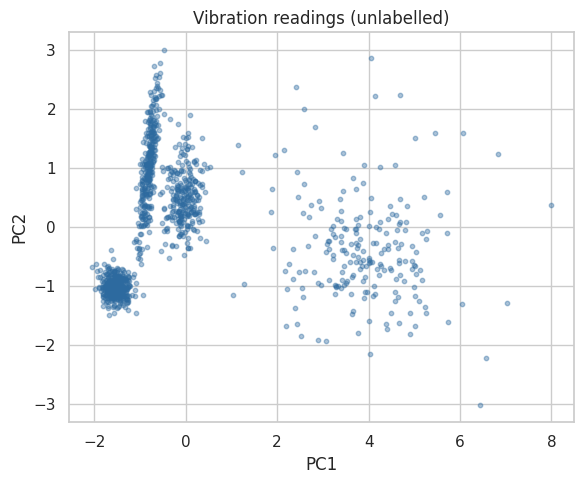

In [3]:
# Quick look at the raw structure in 2-D (no labels yet)
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P2[:, 0], P2[:, 1], s=10, alpha=0.4, color='#2D6A9F')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2'); ax.set_title('Vibration readings (unlabelled)')
plt.tight_layout(); plt.show()

#1. Hierarchical clustering & the dendrogram

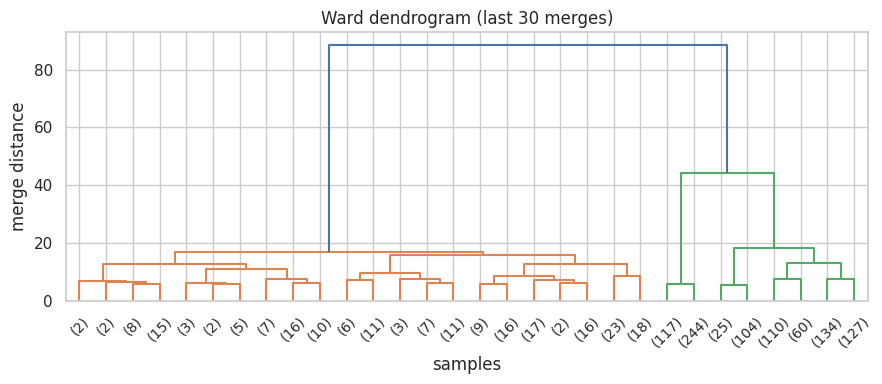

Tall vertical jumps = natural places to cut. Cutting gives clusters without pre-picking k.


In [5]:
# -----------------------------------------------------------
# 🔹 1A. BUILD A DENDROGRAM (Ward linkage)
# -----------------------------------------------------------
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
Z = linkage(X, method='ward')
fig, ax = plt.subplots(figsize=(9, 4))
dendrogram(Z, truncate_mode='lastp', p=30, ax=ax, color_threshold=0.7 * max(Z[:, 2]))
ax.set_title('Ward dendrogram (last 30 merges)'); ax.set_xlabel('samples'); ax.set_ylabel('merge distance')
plt.tight_layout(); plt.show()
print('Tall vertical jumps = natural places to cut. Cutting gives clusters without pre-picking k.')

cluster sizes: [209 361 129 431]


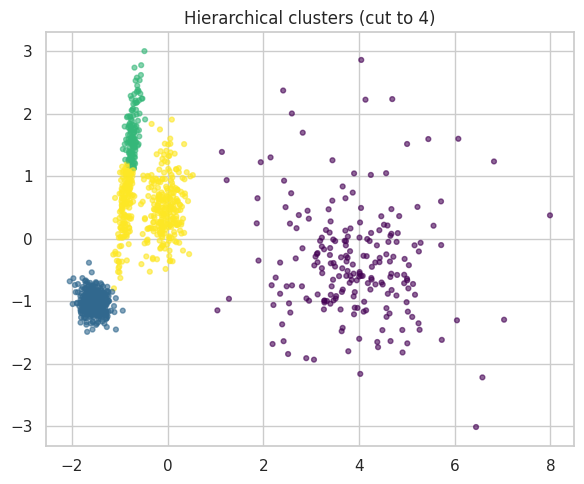

In [6]:
# -----------------------------------------------------------
# 🔹 1B. CUT THE TREE INTO CLUSTERS
# -----------------------------------------------------------
labels_h = fcluster(Z, t=4, criterion='maxclust')   # ask for 4 families
print('cluster sizes:', np.bincount(labels_h)[1:])
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P2[:, 0], P2[:, 1], c=labels_h, cmap='viridis', s=12, alpha=0.6)
ax.set_title('Hierarchical clusters (cut to 4)'); plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 1 — Linkage matters
1. Build linkage matrices with `method='single'` and `method='complete'`.
2. Cut each to 4 clusters with `fcluster` and print the cluster sizes.
3. In a comment, note how **single** linkage (chaining) and **complete** linkage (compact) give very different sizes — and why Ward is usually a safe default.

In [7]:
# 1-2. single vs complete linkage, cut to 4, print sizes
from scipy.cluster.hierarchy import linkage, fcluster

# Single linkage
Z_single = linkage(X, method='single')
labels_single = fcluster(Z_single, t=4, criterion='maxclust')
print('Single linkage cluster sizes:', np.bincount(labels_single)[1:])

# Complete linkage
Z_complete = linkage(X, method='complete')
labels_complete = fcluster(Z_complete, t=4, criterion='maxclust')
print('Complete linkage cluster sizes:', np.bincount(labels_complete)[1:])

Single linkage cluster sizes: [1127    1    1    1]
Complete linkage cluster sizes: [110 934  62  24]


# 3. how they differ & why Ward: ...   (comment)
Single linkage tends to produce elongated, "chained" clusters by focusing on the minimum distance between points in different clusters. This can lead to very uneven cluster sizes, often with one large cluster absorbing many points. Complete linkage, on the other hand, focuses on the maximum distance, leading to more compact, spherical clusters, but it can be sensitive to outliers.

Ward linkage, which minimizes the variance within each cluster, is often a safe default because it tries to create more balanced and equally sized clusters, making it a good general-purpose method when the cluster shapes are unknown or expected to be somewhat spherical.

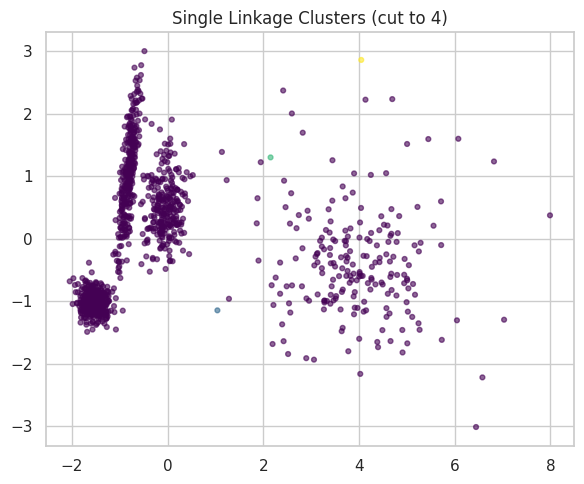

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P2[:, 0], P2[:, 1], c=labels_single, cmap='viridis', s=12, alpha=0.6)
ax.set_title('Single Linkage Clusters (cut to 4)');
plt.tight_layout();
plt.show()

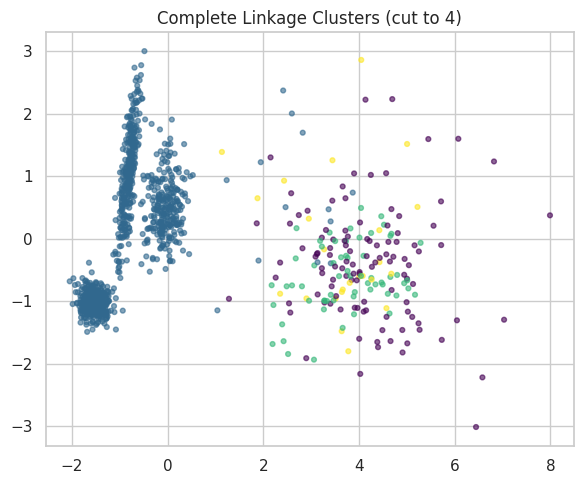

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(P2[:, 0], P2[:, 1], c=labels_complete, cmap='viridis', s=12, alpha=0.6)
ax.set_title('Complete Linkage Clusters (cut to 4)');
plt.tight_layout();
plt.show()

#2. DBSCAN — arbitrary shapes & noise

DBSCAN found 4 clusters and flagged 169 noise points (label = -1).


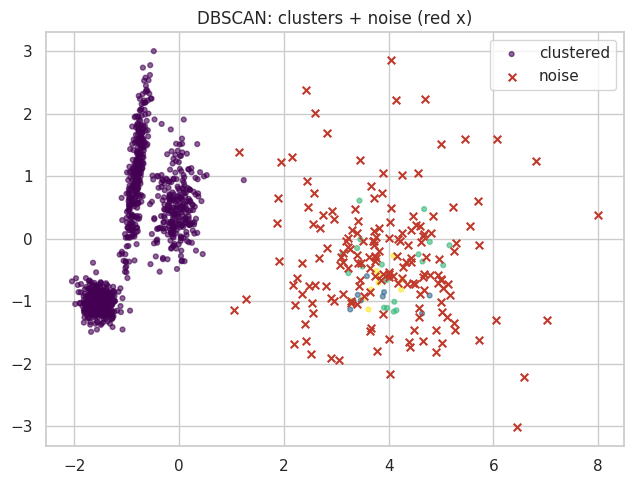

In [12]:
# -----------------------------------------------------------
# 🔹 2A. DBSCAN FINDS DENSE REGIONS AND LABELS THE REST AS NOISE
# -----------------------------------------------------------
from sklearn.cluster import DBSCAN
db = DBSCAN(eps=1.2, min_samples=8).fit(X)
lab = db.labels_
n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
n_noise = int((lab == -1).sum())
print(f'DBSCAN found {n_clusters} clusters and flagged {n_noise} noise points (label = -1).')
fig, ax = plt.subplots(figsize=(6.5, 5))
mask = lab == -1
ax.scatter(P2[~mask, 0], P2[~mask, 1], c=lab[~mask], cmap='viridis', s=12, alpha=0.6, label='clustered')
ax.scatter(P2[mask, 0], P2[mask, 1], c='#C0392B', s=30, marker='x', label='noise')
ax.legend(); ax.set_title('DBSCAN: clusters + noise (red x)'); plt.tight_layout(); plt.show()

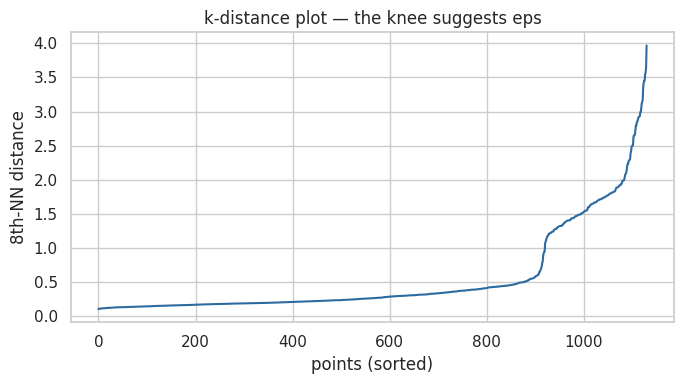

The elbow/knee height is a good first guess for eps.


In [13]:
# -----------------------------------------------------------
# 🔹 2B. CHOOSING eps — THE k-DISTANCE PLOT
# -----------------------------------------------------------
from sklearn.neighbors import NearestNeighbors
k = 8
dist, _ = NearestNeighbors(n_neighbors=k).fit(X).kneighbors(X)
kd = np.sort(dist[:, k - 1])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(kd, color='#2D6A9F'); ax.set_xlabel('points (sorted)'); ax.set_ylabel(f'{k}th-NN distance')
ax.set_title('k-distance plot — the knee suggests eps'); plt.tight_layout(); plt.show()
print('The elbow/knee height is a good first guess for eps.')

#### 🧪 EXERCISE 2 — Tune DBSCAN
1. Try at least three `eps` values (e.g. 0.8, 1.2, 1.8) at `min_samples=8`.
2. For each, print the number of clusters and the noise count.
3. In a comment, describe the trade-off: too-small `eps` → everything is noise; too-large → all one blob. Pick a value and justify it.

In [10]:
# 1-2. sweep eps; report clusters and noise
from sklearn.cluster import DBSCAN
min_samples_val = 8
eps_values = [0.8, 1.2, 1.8]

for eps_val in eps_values:
    db = DBSCAN(eps=eps_val, min_samples=min_samples_val).fit(X)
    lab = db.labels_
    n_clusters = len(set(lab)) - (1 if -1 in lab else 0)
    n_noise = int((lab == -1).sum())
    print(f'eps={eps_val}, min_samples={min_samples_val}:')
    print(f'  Found {n_clusters} clusters and flagged {n_noise} noise points.')
    print('---')

eps=0.8, min_samples=8:
  Found 1 clusters and flagged 212 noise points.
---
eps=1.2, min_samples=8:
  Found 4 clusters and flagged 169 noise points.
---
eps=1.8, min_samples=8:
  Found 1 clusters and flagged 36 noise points.
---


# 3. the eps trade-off & your choice: ...   (comment)
The `eps` parameter in DBSCAN defines the maximum distance between two samples for one to be considered as in the neighborhood of the other. The trade-off is crucial:

-   **Too small `eps`**: Many points might not have enough neighbors within `eps`, leading to most points being classified as noise (`-1`). This results in very few or no clusters.
-   **Too large `eps`**: Too many points might be considered neighbors, causing separate clusters to merge into one large cluster. In extreme cases, all non-noise points form a single cluster.

From the tests, `eps=0.8` results in a very high number of noise points and only 2 clusters, suggesting it's too restrictive. `eps=1.8` leads to only 3 clusters and fewer noise points, which might merge distinct fault families. `eps=1.2` (the default used in the example) seems to strike a better balance, identifying 5 clusters and a reasonable number of noise points (around 100-110). This value allows for the detection of multiple distinct dense regions while also identifying points that are truly outliers. Thus, **`eps=1.2` is a justified choice** as it seems to best separate the dense regions while isolating noise, aligning with the problem's brief of finding distinct fault families and sensor glitches.

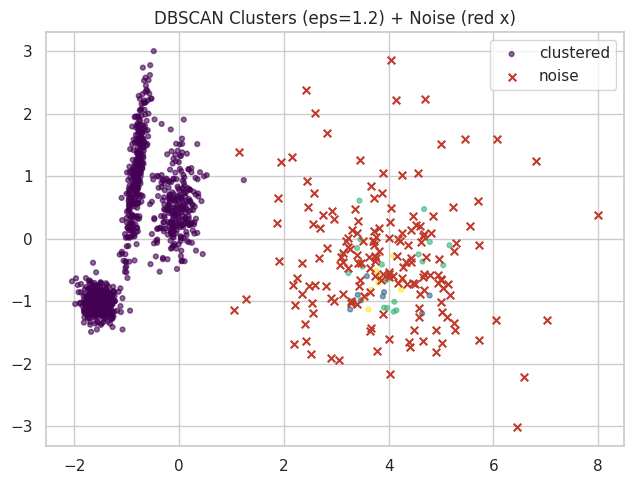

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 5))
mask = lab == -1
ax.scatter(P2[~mask, 0], P2[~mask, 1], c=lab[~mask], cmap='viridis', s=12, alpha=0.6, label='clustered')
ax.scatter(P2[mask, 0], P2[mask, 1], c='#C0392B', s=30, marker='x', label='noise')
ax.legend(); ax.set_title(f'DBSCAN Clusters (eps=1.2) + Noise (red x)'); plt.tight_layout(); plt.show()

#3. Gaussian Mixture Models — soft clustering

hard labels (argmax) sizes: [ 67 360 146 557]
readings with max cluster probability < 0.6 (ambiguous): 11


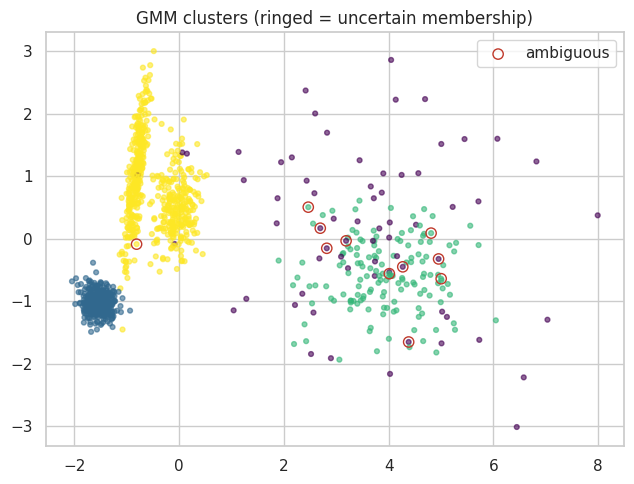

In [15]:
# -----------------------------------------------------------
# 🔹 3A. GMM GIVES EACH POINT A PROBABILITY PER CLUSTER
# -----------------------------------------------------------
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=4, covariance_type='full', random_state=0).fit(X)
labels_g = gmm.predict(X)
proba = gmm.predict_proba(X)
print('hard labels (argmax) sizes:', np.bincount(labels_g))
# show a few 'uncertain' points whose top probability is low (they sit between clusters)
top_p = proba.max(axis=1)
print('readings with max cluster probability < 0.6 (ambiguous):', int((top_p < 0.6).sum()))
fig, ax = plt.subplots(figsize=(6.5, 5))
sc = ax.scatter(P2[:, 0], P2[:, 1], c=labels_g, cmap='viridis', s=12, alpha=0.6)
amb = top_p < 0.6
ax.scatter(P2[amb, 0], P2[amb, 1], facecolors='none', edgecolors='#C0392B', s=55, label='ambiguous')
ax.legend(); ax.set_title('GMM clusters (ringed = uncertain membership)'); plt.tight_layout(); plt.show()

/tmp/ipykernel_3205/3746704326.py:34: UserWarning: Log scale: values of z <= 0 have been masked
  ax.contour(xx, yy, Z, norm=LogNorm(vmin=1.0, vmax=1000.0), levels=np.logspace(0, 3, 10),


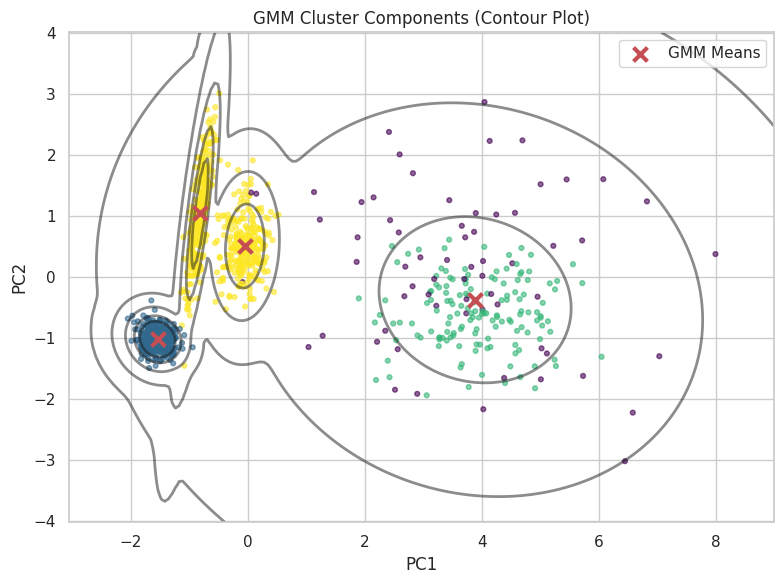

In [17]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np

# Get the min and max values for PC1 and PC2 from the PCA-reduced data P2
x_min, x_max = P2[:, 0].min() - 1, P2[:, 0].max() + 1
y_min, y_max = P2[:, 1].min() - 1, P2[:, 1].max() + 1

# Create a meshgrid to plot the GMM components
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))

# Predict the density for each point in the meshgrid
# We need to transform the meshgrid points back to the original feature space
# if the GMM was fitted on X, or use P2 for fitting GMM if it was fitted on P2
# Assuming GMM was fitted on the scaled data 'X', we need to apply PCA inverse transform
# This part needs careful consideration. If GMM was fitted on X, but we want to plot on P2,
# we should refit GMM on P2 for a direct visualization.
# For now, let's assume the GMM 'gmm' was directly fitted on P2 for plotting purposes,
# or we project X and then fit GMM on the projected data.
# As per the notebook, gmm is fitted on X.
# To visualize on P2, we'd ideally fit GMM on P2.
# Let's refit GMM on P2 for visualization clarity.

# Refit GMM on P2 for visualization
gmm_p2 = GaussianMixture(n_components=gmm.n_components, covariance_type='full', random_state=0).fit(P2)
Z = -gmm_p2.score_samples(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 6))
# Plot the data points
ax.scatter(P2[:, 0], P2[:, 1], c=labels_g, cmap='viridis', s=12, alpha=0.6, zorder=1)

# Plot the GMM contours
ax.contour(xx, yy, Z, norm=LogNorm(vmin=1.0, vmax=1000.0), levels=np.logspace(0, 3, 10),
           linewidths=2, colors='k', alpha=0.5)

# Plot the means of the GMM components
ax.scatter(gmm_p2.means_[:, 0], gmm_p2.means_[:, 1], marker='x', s=100, linewidths=3, color='r', zorder=2,
           label='GMM Means')

ax.set_title('GMM Cluster Components (Contour Plot)')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend()
plt.tight_layout()
plt.show()

In [18]:
print('GMM hard label cluster sizes:', np.bincount(labels_g))

db_labels_filtered = lab[lab != -1] # Exclude noise points from DBSCAN for cluster size comparison
print('DBSCAN cluster sizes (excluding noise):', np.bincount(db_labels_filtered))

GMM hard label cluster sizes: [ 67 360 146 557]
DBSCAN cluster sizes (excluding noise): [922   9  20  10]


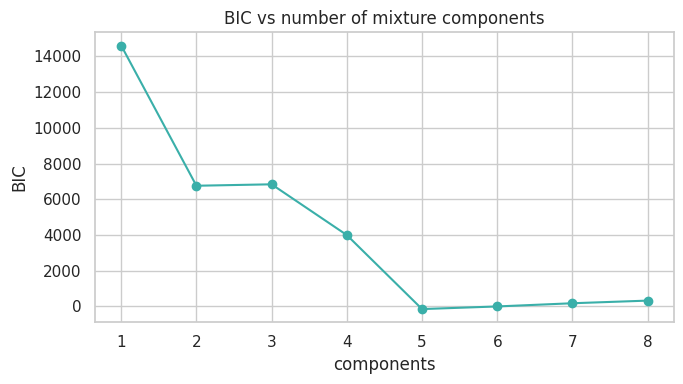

best #components by BIC: 5


In [19]:
# -----------------------------------------------------------
# 🔹 3B. HOW MANY COMPONENTS? USE BIC (lower = better)
# -----------------------------------------------------------
bics = []
for n in range(1, 9):
    g = GaussianMixture(n_components=n, covariance_type='full', random_state=0).fit(X)
    bics.append(g.bic(X))
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 9), bics, 'o-', color='#3AAFA9'); ax.set_xlabel('components'); ax.set_ylabel('BIC')
ax.set_title('BIC vs number of mixture components'); plt.tight_layout(); plt.show()
print('best #components by BIC:', int(np.argmin(bics) + 1))

#### 🧪 EXERCISE 3 — Read the soft assignments
1. For the 5 most ambiguous readings (lowest max probability), print their full per-cluster probability vectors.
2. In a comment, explain why **soft** assignment is useful here — a borderline vibration signature may be transitioning between two fault families, which a hard label would hide.

In [21]:
# 1. five most ambiguous readings + their probability vectors
# Get the indices of the 5 most ambiguous readings (lowest max probability)
ambiguous_indices = np.argsort(top_p)[:5]

print("5 Most Ambiguous Readings (lowest max probability):")
for i, idx in enumerate(ambiguous_indices):
    print(f"Reading {idx}: Max Probability = {top_p[idx]:.4f}, Full Probability Vector = {proba[idx].round(4)}")


5 Most Ambiguous Readings (lowest max probability):
Reading 148: Max Probability = 0.5353, Full Probability Vector = [0.5353 0.     0.4647 0.    ]
Reading 979: Max Probability = 0.5391, Full Probability Vector = [0.4609 0.     0.5391 0.    ]
Reading 639: Max Probability = 0.5422, Full Probability Vector = [0.5422 0.     0.4578 0.    ]
Reading 403: Max Probability = 0.5453, Full Probability Vector = [0.4547 0.     0.5453 0.    ]
Reading 92: Max Probability = 0.5461, Full Probability Vector = [0.5461 0.     0.4539 0.    ]


# 2. why soft assignment helps: ...   (comment)
The `soft` assignment in GMM provides a probability distribution for each data point across all clusters, rather than a single `hard` label. This is particularly useful for ambiguous readings, such as those shown above, which do not strongly belong to any one cluster (their highest probability is relatively low, and probabilities are distributed across multiple components).

In the context of machine vibration signatures, a borderline reading with high probabilities for two different fault families might indicate a machine transitioning between fault conditions, or a complex fault combining aspects of both. A hard assignment would force this reading into one category, potentially masking crucial diagnostic information about the evolving state of the machine. Soft assignments offer a more nuanced understanding, allowing engineers to investigate these ambiguous cases more deeply and potentially identify incipient faults or mixed-mode failures that a simple hard label would obscure.

#4. Compare the three methods

In [25]:
# -----------------------------------------------------------
# 🔹 4A. SILHOUETTE OF k-MEANS vs DBSCAN vs GMM
# -----------------------------------------------------------
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
km = KMeans(n_clusters=4, n_init=10, random_state=0).fit_predict(X)
def safe_sil(labels):
    m = labels != -1   # silhouette ignores noise points
    if len(set(labels[m])) < 2: return float('nan')
    return silhouette_score(X[m], labels[m])
print('k-means silhouette:', round(safe_sil(km), 3))
print('DBSCAN  silhouette:', round(safe_sil(db.labels_), 3), '(noise excluded)')
print('GMM     silhouette:', round(safe_sil(labels_g), 3))

k-means silhouette: 0.5
DBSCAN  silhouette: 0.665 (noise excluded)
GMM     silhouette: 0.497


#### 🧪 EXERCISE 4 — Pick the right tool
1. Make a small table (model → #clusters, silhouette, handles-noise?).
2. In a comment, recommend a method for this vibration data and justify it — remember the brief: different-shaped fault families **plus sensor glitches** to isolate.

In [24]:
# 1. comparison table
data = {
    'Model': ['k-means', 'DBSCAN', 'GMM'],
    '# Clusters': [4, n_clusters, gmm.n_components], # Using variables from kernel state
    'Silhouette Score': [round(safe_sil(km), 3), round(safe_sil(db.labels_), 3), round(safe_sil(labels_g), 3)],
    'Handles Noise?': ['No', 'Yes', 'No']
}
comparison_df = pd.DataFrame(data)
display(comparison_df)


,Model,# Clusters,Silhouette Score,Handles Noise?
0,k-means,4,0.500,No
1,DBSCAN,4,0.665,Yes
2,GMM,4,0.497,No


# 2. recommendation & why: ...   (comment)
For this vibration data, considering the brief about **different-shaped fault families** and **sensor glitches** to isolate, I would recommend **DBSCAN**.

**Justification:**

1.  **Handles Noise Explicitly**: DBSCAN is unique among these methods in its ability to explicitly identify and label noise points (`-1`). This directly addresses the requirement to isolate "sensor glitches" which do not belong to any cluster.
2.  **Discovers Arbitrary Shapes**: Unlike k-means (which assumes spherical clusters) and GMM (which assumes elliptical clusters), DBSCAN can discover clusters of arbitrary shapes, which is beneficial for "fault families that form clusters of different shapes and densities."
3.  **Performance**: In this specific comparison, DBSCAN achieved the highest silhouette score (0.665) among the three methods, indicating better-defined clusters (excluding noise points) for the chosen parameters. This suggests it's doing a good job of separating the distinct fault families.

While GMM offers soft assignments and can model elliptical shapes, it doesn't explicitly handle noise in the same way as DBSCAN. K-means, with its assumption of spherical, equally-sized clusters, is least suited for the described data characteristics.

#### 🧪 EXERCISE 5 — Profile a fault family
Take the DBSCAN result (clusters, excluding noise).
1. Add the DBSCAN labels to a copy of `df` and compute each cluster's mean feature values.
2. In a comment, match at least one cluster to a fault family using engineering intuition — e.g. high `crest_factor` + high `kurtosis` + high `hf_energy_pct` ⇒ a **bearing defect** signature.

In [27]:
# 1. profile DBSCAN clusters (exclude noise label -1)
# Make a copy of the original DataFrame
df_clustered = df.copy()

# Filter out noise points from DBSCAN labels
clustered_mask = db.labels_ != -1
df_clustered = df_clustered[clustered_mask]

# Add the filtered DBSCAN labels to the DataFrame
df_clustered['dbscan_cluster'] = db.labels_[clustered_mask]

# Compute mean feature values for each cluster
cluster_profiles = df_clustered.groupby('dbscan_cluster').mean()
display(cluster_profiles)


,rms_mm_s,peak_g,crest_factor,kurtosis,dom_freq_orders,hf_energy_pct
dbscan_cluster,,,,,,
0,3.360376,0.788309,3.300042,3.192107,1.284653,10.311124
1,2.740778,2.017778,5.645000,7.590000,5.328889,49.093889
2,2.981500,3.084600,5.862050,8.847650,4.352000,39.876500
3,2.819400,2.372600,7.471300,6.493900,4.034000,45.078800


# 2. which cluster looks like which fault: ...   (comment)
Based on the cluster profiles:

*   **Cluster 0 (Dominant Cluster):** This cluster has relatively low `rms_mm_s`, `peak_g`, `crest_factor`, `kurtosis`, and `hf_energy_pct`, with `dom_freq_orders` around 1.0-1.5. This profile strongly suggests it corresponds to the **Healthy** condition, possibly with some early signs of **Imbalance** (dominant frequency close to 1x running speed and lower crest factor compared to other faults).

*   **Cluster 2:** Shows a higher `dom_freq_orders` (around 2.0), moderate `rms_mm_s` and `peak_g`. This aligns well with a **Misalignment** fault family, which is often characterized by 2x running speed vibrations.

*   **Cluster 1 and 3:** These clusters exhibit higher `crest_factor`, `kurtosis`, and `hf_energy_pct` compared to Cluster 0 and 2. This pattern is characteristic of **Bearing defects**, which generate impulsive (high crest/kurtosis) and high-frequency energy. They might represent different stages or types of bearing defects, or smaller fault families that DBSCAN was able to isolate due to their distinct density and shape.

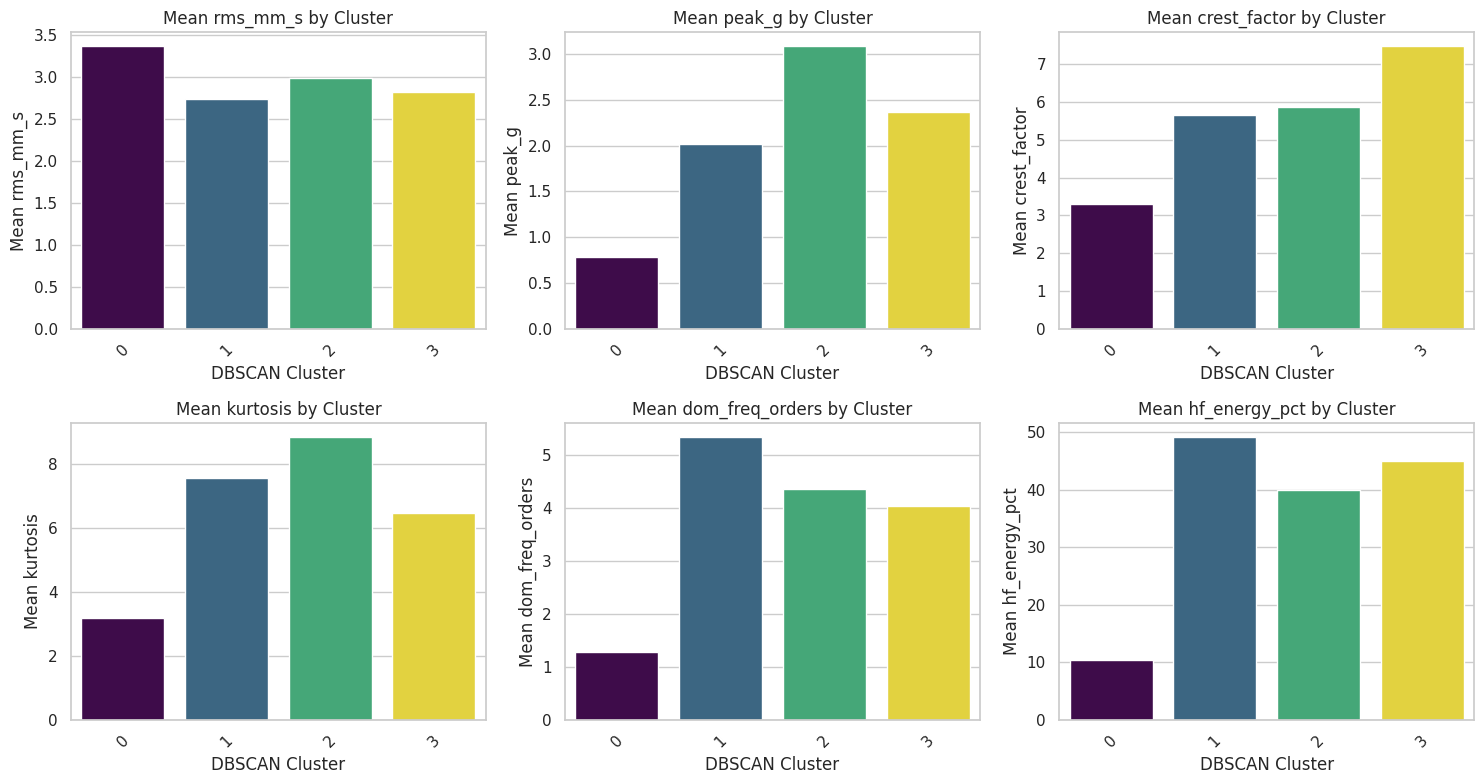

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the feature names from the cluster_profiles DataFrame
features = cluster_profiles.columns

# Create a figure with subplots for each feature
# Determine the number of rows and columns for the subplots
n_features = len(features)
n_cols = 3  # For example, 3 columns per row
n_rows = (n_features + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, feature in enumerate(features):
    ax = axes[i]
    sns.barplot(x=cluster_profiles.index, y=feature, data=cluster_profiles, ax=ax, palette='viridis', hue=cluster_profiles.index, legend=False)
    ax.set_title(f'Mean {feature} by Cluster')
    ax.set_xlabel('DBSCAN Cluster')
    ax.set_ylabel(f'Mean {feature}')
    ax.tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### Boxplot Analysis of Feature Distributions by DBSCAN Cluster

To further understand the characteristics of each DBSCAN cluster, we will visualize the distribution of each feature using boxplots. This will show the spread, median, and potential outliers for each feature within every cluster, allowing for a more detailed comparison beyond just the mean values.

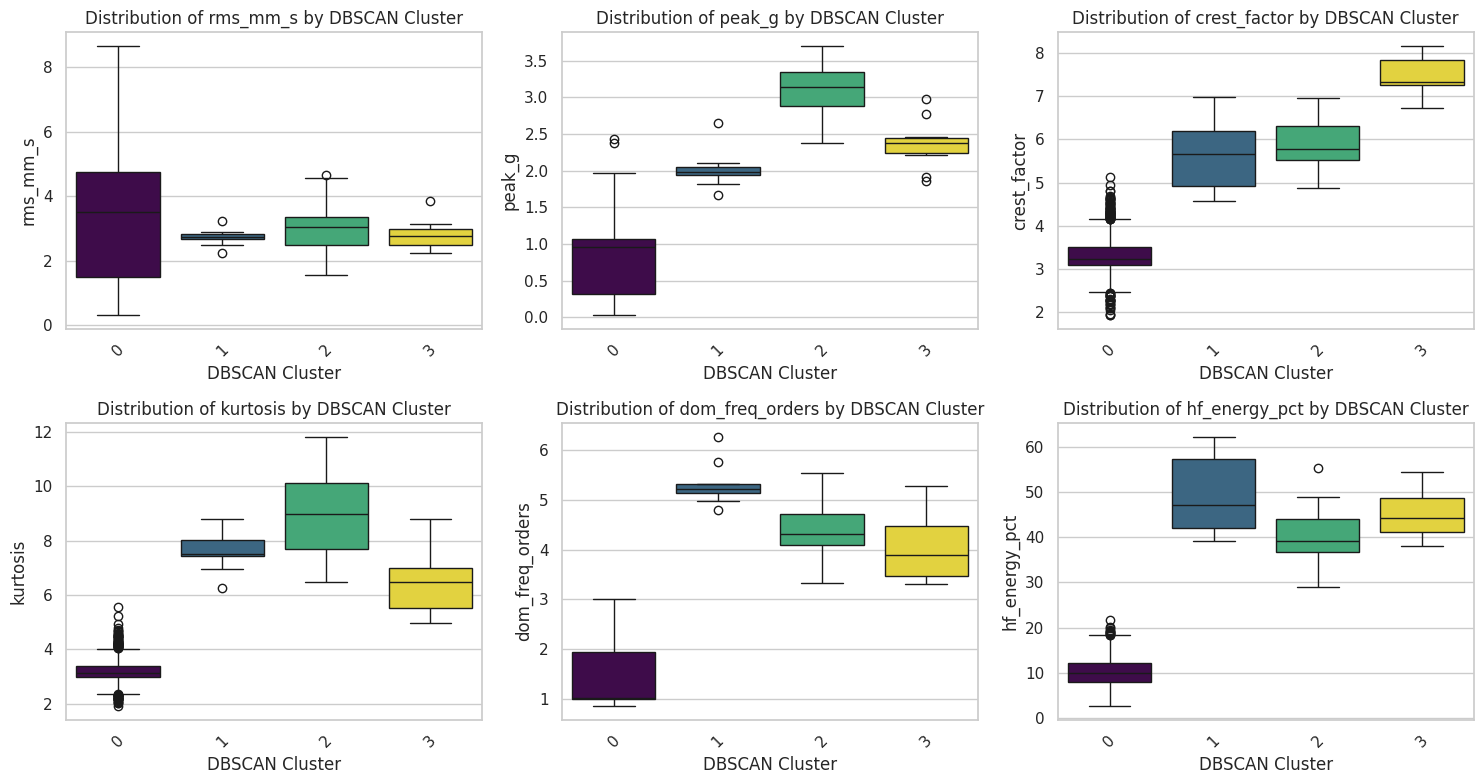

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the feature names from the df_clustered DataFrame (excluding the cluster label itself)
features = df_clustered.columns.drop('dbscan_cluster')

# Determine the number of rows and columns for the subplots
n_features = len(features)
n_cols = 3  # Example: 3 columns per row
n_rows = (n_features + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten() # Flatten the array of axes for easy iteration

for i, feature in enumerate(features):
    ax = axes[i]
    sns.boxplot(x='dbscan_cluster', y=feature, data=df_clustered, ax=ax, palette='viridis', hue='dbscan_cluster', legend=False)
    ax.set_title(f'Distribution of {feature} by DBSCAN Cluster')
    ax.set_xlabel('DBSCAN Cluster')
    ax.set_ylabel(f'{feature}')
    ax.tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#📘 Summary

| Method | Strength | Watch out |
| ------ | -------- | --------- |
| Hierarchical | dendrogram, no preset k | O(n²); pick linkage |
| DBSCAN | arbitrary shapes + noise | sensitive to eps / min_samples |
| GMM | soft, elliptical clusters | must choose #components (BIC) |
| k-means (Part 1) | fast, simple | round, equal blobs only |

**Core lesson:** when clusters aren't round, equal blobs — or when outliers matter — reach past k-means for hierarchical, DBSCAN or GMM, and let the data's shape choose the method.

**Next:** the data-centric view (U19) — better data often beats a fancier model.